<a href="https://colab.research.google.com/github/FraSeb6/Similarity_Ish_Abstract/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding Similar arXiv Abstracts (Shingling + MinHash + LSH)

Goal: detect pairs of **near-duplicate scientific abstracts** in the arXiv dataset.

Similarity measure: **Jaccard similarity**, estimated efficiently with **MinHash**, and
scaled to large data with **Locality-Sensitive Hashing (LSH)**.

Pipeline: `shingling -> MinHash signatures -> LSH candidate pairs -> validation (precision & recall) -> scalability`.

## 0. Setup & Configuration

In [1]:
import os
import json
import time
import zlib
import random
import zipfile
import itertools
from collections import defaultdict   # used for the LSH buckets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm   # simple progress bar for the long loops

print("Setup ready. NumPy version:", np.__version__)

Setup ready. NumPy version: 2.5.0


/Users/memmo/Documents/GitHub/Similarity_Ish_Abstract/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)        # fix Python's random generator so every run is identical
np.random.seed(SEED)     # fix NumPy's random generator (used for the hash functions)

# ---------- Kaggle dataset ----------
DATASET   = "Cornell-University/arxiv"
JSON_FILE = "arxiv-metadata-oai-snapshot.json"

# ---------- GLOBAL SWITCH: subsampling (required by the assignment) ----------
USE_SUBSAMPLE  = True      # True  -> work on a small slice (fast, for testing)
                           # False -> work on the full dataset
SUBSAMPLE_SIZE = 50_000    # how many abstracts to keep when subsampling

# ---------- Preprocessing ----------
MIN_ABSTRACT_WORDS = 20    # drop abstracts shorter than this (stubs, 'paper withdrawn' notices)

# ---------- Shingling ----------
SHINGLE_K = 9             # character-level k-shingles (k=9 chosen empirically, see Section 2)

# ---------- MinHash ----------
N_HASHES = 100            # number of hash functions = length of each MinHash signature
PRIME    = 2_147_483_647  # a large prime (2^31 - 1) used by the hash functions h(x) = (a*x + b) % PRIME

# ---------- LSH target ----------
TARGET_THRESHOLD = 0.5    # we want LSH to catch pairs whose Jaccard similarity is >= 0.5

mode = f"SUBSAMPLE ({SUBSAMPLE_SIZE:,} docs)" if USE_SUBSAMPLE else "FULL DATASET"
print("Mode:", mode)
print(f"Signature length = {N_HASHES} | target Jaccard threshold = {TARGET_THRESHOLD}")

Mode: SUBSAMPLE (50,000 docs)
Signature length = 100 | target Jaccard threshold = 0.5


## 1. Data Ingestion (streaming)

The arXiv file is ~4 GB of text, one JSON object per line. We **never load it all into memory**:
we read it **line by line**, keep only the `abstract` field, drop abstracts that are too short,
and finally collect the result in a pandas DataFrame.

In [3]:
# ---------- Kaggle credentials ----------
# Replace "xxxxxx" with your own username/key to RUN the download,
# then put them back to "xxxxxx" before sharing the notebook.
os.environ["KAGGLE_USERNAME"] = "xxxxxx"
os.environ["KAGGLE_KEY"]      = "xxxxxx"

# Download the dataset from Kaggle (it skips the download if the file is already there)
!pip install -q kaggle
!kaggle datasets download -d {DATASET}

# The download is a .zip; extract just the JSON file we need
with zipfile.ZipFile("arxiv.zip") as z:
    z.extract(JSON_FILE)

print("Dataset ready:", JSON_FILE)


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset ready: arxiv-metadata-oai-snapshot.json


In [4]:
def load_abstracts(path, use_subsample, subsample_size, min_words):
    ids = []          # paper IDs we keep
    abstracts = []    # abstract texts we keep
    n_seen = 0        # how many lines we have read so far

    with open(path, encoding="utf-8") as f:
        for line in f:                                 # read ONE line at a time -> low memory
            if use_subsample and n_seen >= subsample_size:
                break                                  # stop early when we are subsampling
            n_seen += 1

            record = json.loads(line)                  # parse the JSON object on this line
            abstract = record["abstract"]              # keep only the field we need

            if len(abstract.split()) < min_words:      # count the words in the abstract
                continue                               # skip it if it is too short

            ids.append(record["id"])
            abstracts.append(abstract)

    print(f"Read {n_seen:,} lines, kept {len(abstracts):,} abstracts "
          f"(dropped {n_seen - len(abstracts):,} too short)")

    # collect the two lists into a DataFrame (one row per abstract)
    return pd.DataFrame({"id": ids, "abstract": abstracts})

In [5]:
t0 = time.time()
df = load_abstracts(
    JSON_FILE,
    use_subsample=USE_SUBSAMPLE,
    subsample_size=SUBSAMPLE_SIZE,
    min_words=MIN_ABSTRACT_WORDS,
)
print(f"Loaded in {time.time() - t0:.1f}s")

# Quick look at the first few rows
df.head(3)

Read 50,000 lines, kept 49,327 abstracts (dropped 673 too short)
Loaded in 0.5s


,id,abstract
0,0704.0001,A fully differential calculation in perturba...
1,0704.0002,"We describe a new algorithm, the $(k,\ell)$-..."
2,0704.0003,The evolution of Earth-Moon system is descri...


## 2. Shingling

We turn each abstract into a **set of k-shingles**: every substring of `k` consecutive characters.
Two abstracts that share many shingles are similar, so the **Jaccard similarity of their shingle
sets** is exactly what we want to measure.

**Why character-level k=9?** We actually tried two values and let the validation results decide:

- With **k=5** the shingles are too common — short substrings like `" the"`, `"tion"` or `"ing "`
  appear in almost every English abstract. Their MinHash values then collide across unrelated
  documents, which floods LSH with false positives: about **50k candidate pairs**, **precision only
  a few percent**, and one giant "cluster" of **681 completely unrelated papers**.
- With **k=9** the shingles are **distinctive**: a 9-character substring is far rarer, so unrelated
  abstracts stop colliding. Candidate pairs dropped to a **few hundred**, **precision jumped to
  ~50-60%**, recall stayed high, and the largest cluster became a **genuine set of near-identical
  papers**.

So k=9 is our choice, and it matches the textbook guidance that longer/normal documents need a
larger k to keep shingles specific. (This is also a nice illustration of *why* we measure quality:
without precision and recall we would never have spotted the k=5 problem.)

We **hash** each shingle into an integer with CRC32 (integers are smaller than strings and MinHash
needs numbers), and we keep only the lower **31 bits** so every shingle stays below `PRIME`.

In [6]:
def normalize(text):
    # lowercase, then collapse every run of whitespace (spaces, newlines, tabs) into a single space
    return " ".join(text.lower().split())


def shingle_set(text, k=SHINGLE_K):
    text = normalize(text)                              # clean the text first
    shingles = set()                                    # a set keeps each shingle only once
    for i in range(len(text) - k + 1):                  # slide a window of k characters
        piece = text[i:i + k]                           # one k-character shingle
        h = zlib.crc32(piece.encode()) & 0x7FFFFFFF     # hash to an integer, keep lower 31 bits
        shingles.add(h)                                 # duplicates are ignored by the set
    return shingles

In [7]:
# Demo: turn the first abstract into its shingle set
demo_text = df["abstract"].iloc[0]
demo_shingles = shingle_set(demo_text)

print("Abstract length (characters):", len(normalize(demo_text)))
print(f"Number of unique {SHINGLE_K}-shingles:", len(demo_shingles))
print("A few hashed shingles:       ", list(demo_shingles)[:5])

Abstract length (characters): 980
Number of unique 9-shingles: 899
A few hashed shingles:        [1227995139, 988133381, 462764050, 1520732184, 1065730073]


## 3. MinHash

Comparing full shingle sets for every pair of documents would be far too expensive. **MinHash**
compresses each document's shingle set into a short **signature** of `N_HASHES` numbers.

We pick `N_HASHES` random hash functions of the form `h(x) = (a*x + b) % PRIME`. For one document,
the signature value at position *j* is the **minimum** of hash function *j* over all the document's
shingles.

**Key property:** the probability that two documents share the same value at a given signature
position equals their **Jaccard similarity**. So the fraction of equal positions between two
signatures is an *estimate* of their Jaccard similarity — computed on 100 numbers instead of
thousands of shingles.

In [8]:
# Create N_HASHES random hash functions: one (a, b) pair per function.
# Because we seeded NumPy in the setup, these are always the same.
A = np.random.randint(1, PRIME, size=N_HASHES, dtype=np.uint64)   # the 'a' coefficients
B = np.random.randint(0, PRIME, size=N_HASHES, dtype=np.uint64)   # the 'b' coefficients

print("Created", N_HASHES, "hash functions.")

Created 100 hash functions.


In [9]:
def minhash_signature(shingles):
    # start every position at the largest possible value, so any real hash will be smaller
    sig = np.full(N_HASHES, np.iinfo(np.uint64).max, dtype=np.uint64)
    for x in shingles:                       # for each shingle in this document
        h = (A * x + B) % PRIME              # apply ALL N_HASHES hash functions to it at once
        sig = np.minimum(sig, h)            # position by position, keep the smallest value seen
    return sig                               # the document's MinHash signature (length N_HASHES)

In [10]:
def build_signatures(frame):
    n = len(frame)
    # one row per document, N_HASHES columns
    signatures = np.zeros((n, N_HASHES), dtype=np.uint64)
    for i, text in enumerate(tqdm(frame["abstract"], desc="MinHash")):
        signatures[i] = minhash_signature(shingle_set(text))
    return signatures

In [11]:
t0 = time.time()
signatures = build_signatures(df)
print(f"Built {signatures.shape[0]:,} signatures of length {signatures.shape[1]} "
      f"in {time.time() - t0:.1f}s")

# the first 10 values of the first document's signature
print("Example signature (first 10 values):", signatures[0][:10])

MinHash: 100%|██████████| 49327/49327 [00:55<00:00, 883.75it/s] 

Built 49,327 signatures of length 100 in 55.8s
Example signature (first 10 values): [5836694 6212603 3619743 2039971 3563924 1326447 1463078  917629 1382929
  542856]


## 4. LSH (Locality-Sensitive Hashing)

Even with short signatures, comparing all pairs is still O(n²). **LSH** avoids that: it splits each
signature into `b` **bands** of `r` rows (with `b * r = N_HASHES`). Two documents that have an
**identical band** land in the same bucket and become a **candidate pair**. We only ever compare
candidates, never all pairs.

The chance that a pair becomes a candidate follows the **S-curve** `1 - (1 - s^r)^b`, whose steep
point sits near the threshold `t ≈ (1/b)^(1/r)`. Instead of hardcoding `b` and `r`, we **derive**
them: we look for the split of 100 hashes whose threshold is closest to our `TARGET_THRESHOLD = 0.5`.

In [12]:
def choose_bands_rows(n_hashes, target_threshold):
    # Try every way to split the signature into b bands of r rows (with b * r = n_hashes),
    # and keep the split whose theoretical threshold (1/b)^(1/r) is closest to our target.
    best = None
    for b in range(1, n_hashes + 1):
        if n_hashes % b != 0:                  # b must divide n_hashes exactly
            continue
        r = n_hashes // b                      # rows per band
        t = (1 / b) ** (1 / r)                 # the similarity where this split "switches on"
        if best is None or abs(t - target_threshold) < abs(best[2] - target_threshold):
            best = (b, r, t)                   # remember the closest split so far
    return best


BANDS, ROWS, LSH_THRESHOLD = choose_bands_rows(N_HASHES, TARGET_THRESHOLD)
print(f"Chosen split: {BANDS} bands x {ROWS} rows  (b * r = {BANDS * ROWS})")
print(f"Target threshold = {TARGET_THRESHOLD} | actual LSH threshold = {LSH_THRESHOLD:.3f}")

Chosen split: 20 bands x 5 rows  (b * r = 100)
Target threshold = 0.5 | actual LSH threshold = 0.549


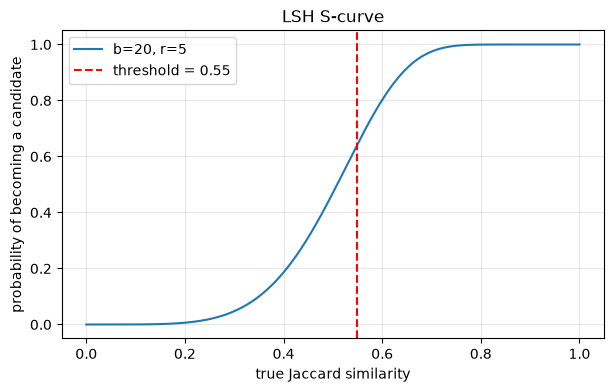

In [13]:
# Visualize the S-curve: the probability that a pair becomes a candidate as a function of
# their true Jaccard similarity. The curve rises steeply around the LSH threshold.
s = np.linspace(0, 1, 200)
prob = 1 - (1 - s ** ROWS) ** BANDS

plt.figure(figsize=(7, 4))
plt.plot(s, prob, label=f"b={BANDS}, r={ROWS}")
plt.axvline(LSH_THRESHOLD, color="red", linestyle="--", label=f"threshold = {LSH_THRESHOLD:.2f}")
plt.xlabel("true Jaccard similarity")
plt.ylabel("probability of becoming a candidate")
plt.title("LSH S-curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
def lsh_candidate_pairs(signatures, bands, rows):
    num_docs = signatures.shape[0]
    candidates = set()                              # collects unique candidate pairs
    for band in range(bands):                       # process one band at a time
        start = band * rows                         # this band covers rows [start, start+rows)
        buckets = defaultdict(list)                 # bucket key -> list of document indices
        for doc in range(num_docs):
            key = signatures[doc, start:start + rows].tobytes()  # this doc's slice in this band
            buckets[key].append(doc)                # docs with an identical slice share a bucket
        for docs in buckets.values():
            if len(docs) > 1:                       # a bucket with 2+ docs produces candidate pairs
                for pair in itertools.combinations(docs, 2):
                    candidates.add(pair)            # add every pair from that bucket
    return candidates

In [15]:
t0 = time.time()
candidate_pairs = lsh_candidate_pairs(signatures, BANDS, ROWS)
print(f"Found {len(candidate_pairs):,} candidate pairs in {time.time() - t0:.1f}s")

Found 380 candidate pairs in 0.5s


## 5. Validation: Precision & Recall

LSH is fast but approximate, so we must check its quality. We measure **two** numbers:

- **Precision** = of the candidate pairs LSH returned, how many are *truly* similar?
- **Recall** = of all the *truly* similar pairs, how many did LSH actually find?

To know the truth we need a **ground truth**. On a small subsample (a few thousand documents) we
compute the **exact** Jaccard similarity of **all** pairs by brute force — this is O(n²), so it is
only affordable on a small slice, but it gives us the real answer. We then compare the LSH
candidates (restricted to that same subsample) against this ground truth.

Measuring recall is the part the simpler implementations skip: precision alone can't tell you how
many similar pairs you *missed*.

In [16]:
def jaccard(set_a, set_b):
    inter = len(set_a & set_b)                  # shingles the two documents share
    union = len(set_a) + len(set_b) - inter     # shingles in either one (inclusion-exclusion)
    return inter / union if union else 0.0      # the exact Jaccard similarity


def ground_truth_pairs(frame, n_docs, threshold):
    # shingle the first n_docs documents ONCE, so the double loop doesn't redo the work
    shingle_sets = [shingle_set(frame["abstract"].iloc[i]) for i in range(n_docs)]
    truly_similar = set()
    for i in tqdm(range(n_docs), desc="Ground truth"):
        for j in range(i + 1, n_docs):                       # every pair (i, j) with i < j
            if jaccard(shingle_sets[i], shingle_sets[j]) >= threshold:
                truly_similar.add((i, j))                    # this pair really is similar
    return truly_similar, shingle_sets

In [17]:
GROUND_TRUTH_SIZE = 4000   # small enough that comparing ALL pairs by brute force is feasible

t0 = time.time()
truly_similar, gt_shingles = ground_truth_pairs(df, GROUND_TRUTH_SIZE, LSH_THRESHOLD)
print(f"Brute force over {GROUND_TRUTH_SIZE:,} docs took {time.time() - t0:.1f}s")
print(f"Truly similar pairs (true Jaccard >= {LSH_THRESHOLD:.2f}): {len(truly_similar):,}")

Ground truth: 100%|██████████| 4000/4000 [01:00<00:00, 66.45it/s] 

Brute force over 4,000 docs took 60.8s
Truly similar pairs (true Jaccard >= 0.55): 7


In [18]:
# Keep only the LSH candidates that live inside the ground-truth subsample,
# so candidates and ground truth are measured on the SAME set of documents.
lsh_in_subset = {(i, j) for (i, j) in candidate_pairs
                 if i < GROUND_TRUTH_SIZE and j < GROUND_TRUTH_SIZE}

found_and_true = lsh_in_subset & truly_similar      # candidates that really are similar

# NOTE: this precision is on the few candidates inside the subsample (small sample) -- it is here
# only so it pairs with recall on the SAME documents. The robust precision over ALL candidate pairs
# is computed in the next cell.
precision = len(found_and_true) / len(lsh_in_subset) if lsh_in_subset else 0.0
recall    = len(found_and_true) / len(truly_similar) if truly_similar else 0.0

print(f"LSH candidate pairs inside the subsample: {len(lsh_in_subset):,}")
print(f"Precision (subsample only): {precision:.1%}")
print(f"Recall:                     {recall:.1%}   (of the truly similar pairs, how many LSH caught)")

LSH candidate pairs inside the subsample: 12
Precision (subsample only): 50.0%
Recall:                     85.7%   (of the truly similar pairs, how many LSH caught)


Global precision over all 380 candidate pairs: 63.2%


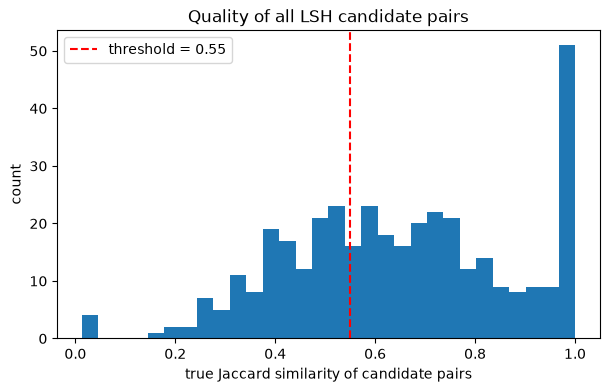

In [19]:
# Quality of EVERY candidate pair (all of them, not just the few inside the ground-truth slice).
# We compute the true Jaccard of each candidate, caching shingle sets so each doc is shingled once.
shingle_cache = {}
def doc_shingles(doc):
    if doc not in shingle_cache:
        shingle_cache[doc] = shingle_set(df["abstract"].iloc[doc])
    return shingle_cache[doc]

all_sims = np.array([jaccard(doc_shingles(i), doc_shingles(j)) for (i, j) in candidate_pairs])

# Global precision: over ALL candidates, the fraction that are truly similar (robust, not just 12 pairs)
global_precision = (all_sims >= LSH_THRESHOLD).mean()
print(f"Global precision over all {len(candidate_pairs):,} candidate pairs: {global_precision:.1%}")

plt.figure(figsize=(7, 4))
plt.hist(all_sims, bins=30)
plt.axvline(LSH_THRESHOLD, color="red", linestyle="--", label=f"threshold = {LSH_THRESHOLD:.2f}")
plt.xlabel("true Jaccard similarity of candidate pairs")
plt.ylabel("count")
plt.title("Quality of all LSH candidate pairs")
plt.legend()
plt.show()

## 6. Duplicate Clusters (optional)

So far we have **pairs**. But a paper often appears in several near-identical versions, so the same
abstract can be paired with many others. We can recover these **groups** with a tiny bit of graph
theory:

- build a graph where each **node** is a document and each **edge** is an LSH candidate pair;
- the **connected components** of that graph are the clusters of near-duplicate abstracts.

We find the components with a simple depth-first traversal (no external library). Each cluster is
typically a set of versions of the same paper.

In [20]:
def connected_components(pairs):
    # build an adjacency list: each document -> the set of documents it is paired with
    graph = defaultdict(set)
    for i, j in pairs:
        graph[i].add(j)
        graph[j].add(i)

    visited = set()
    components = []
    for start in graph:                       # try every document that appears in some pair
        if start in visited:
            continue                          # already placed in a component we found earlier
        # explore everything reachable from 'start' -> that is one connected component
        stack = [start]
        component = []
        while stack:
            node = stack.pop()                # take a document to visit
            if node in visited:
                continue
            visited.add(node)
            component.append(node)
            stack.extend(graph[node] - visited)   # queue its not-yet-visited neighbours
        components.append(component)
    return components

In [21]:
clusters = connected_components(candidate_pairs)
print(f"Found {len(clusters):,} duplicate groups (each is a set of 2+ near-identical abstracts)")

# distribution of cluster sizes, largest first
sizes = sorted((len(c) for c in clusters), reverse=True)
print("Ten largest cluster sizes:", sizes[:10])

Found 337 duplicate groups (each is a set of 2+ near-identical abstracts)
Ten largest cluster sizes: [7, 4, 4, 3, 3, 3, 3, 3, 3, 3]


In [22]:
# Look at the largest cluster: its abstracts should be near-duplicates
# (very often different versions, v1/v2/v3, of the same paper).
biggest = max(clusters, key=len)
print(f"Largest cluster has {len(biggest)} abstracts:\n")
for doc in sorted(biggest)[:5]:                       # show up to 5 of them
    snippet = df["abstract"].iloc[doc][:120].strip()
    print(f"  id={df['id'].iloc[doc]}  |  {snippet} ...")

Largest cluster has 7 abstracts:

  id=0710.4022  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4023  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4024  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4025  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...
  id=0710.4028  |  In this series of seven papers, predominantly by means of elementary
analysis, we establish a number of identities rel ...


## 7. Scalability

The assignment requires the pipeline to scale to the full ~3M abstracts, so we check how the running
time grows. We re-run the two heavy stages — **MinHash** and **LSH** — on increasingly large prefixes
of the dataset (5k, 10k, 20k, 40k documents) and time each stage separately.

If the implementation is sound, both stages grow **roughly linearly** in the number of documents `n`,
with no quadratic blow-up. That is what lets the same code run on the full dataset just by setting
`USE_SUBSAMPLE = False`.

In [23]:
def benchmark(frame, sizes):
    rows = []
    for n in sizes:
        sub = frame.iloc[:n]                              # take the first n documents

        t0 = time.time()
        sig = build_signatures(sub)                       # stage 1: MinHash
        t_minhash = time.time() - t0

        t1 = time.time()
        cands = lsh_candidate_pairs(sig, BANDS, ROWS)     # stage 2: LSH
        t_lsh = time.time() - t1

        rows.append({"n": n, "minhash_s": t_minhash, "lsh_s": t_lsh,
                     "total_s": t_minhash + t_lsh, "candidates": len(cands)})
        print(f"n={n:>7,} | minhash {t_minhash:6.1f}s | lsh {t_lsh:5.1f}s | candidates {len(cands):>7,}")
    return pd.DataFrame(rows)


# increasing prefixes of the dataset (kept within what we actually loaded)
SIZES = [n for n in (5_000, 10_000, 20_000, 40_000) if n <= len(df)]
bench = benchmark(df, SIZES)
bench

MinHash: 100%|██████████| 5000/5000 [00:06<00:00, 732.04it/s]


n=  5,000 | minhash    6.8s | lsh   0.2s | candidates      15


MinHash: 100%|██████████| 10000/10000 [00:11<00:00, 850.92it/s]


n= 10,000 | minhash   11.8s | lsh   0.1s | candidates      35


MinHash: 100%|██████████| 20000/20000 [00:21<00:00, 927.87it/s] 


n= 20,000 | minhash   21.6s | lsh   0.4s | candidates      88


MinHash: 100%|██████████| 40000/40000 [00:43<00:00, 916.26it/s] 


n= 40,000 | minhash   43.7s | lsh   0.6s | candidates     298


,n,minhash_s,lsh_s,total_s,candidates
0,5000,6.831880,0.170639,7.002519,15
1,10000,11.753616,0.135392,11.889008,35
2,20000,21.555710,0.423818,21.979528,88
3,40000,43.656970,0.645481,44.302451,298


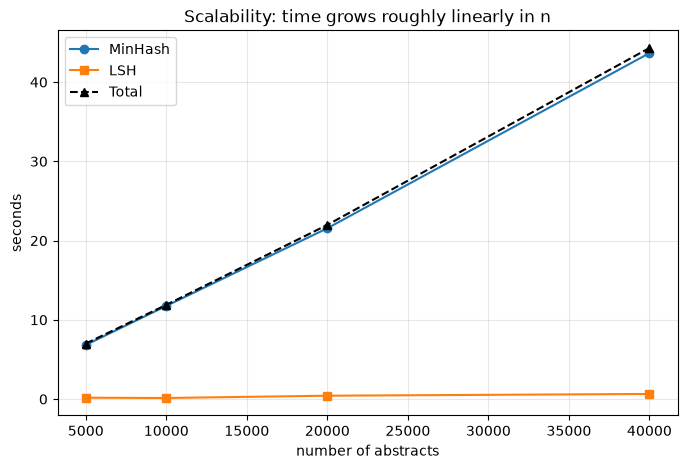

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(bench["n"], bench["minhash_s"], "o-", label="MinHash")
plt.plot(bench["n"], bench["lsh_s"], "s-", label="LSH")
plt.plot(bench["n"], bench["total_s"], "^--", color="black", label="Total")
plt.xlabel("number of abstracts")
plt.ylabel("seconds")
plt.title("Scalability: time grows roughly linearly in n")
plt.legend()
plt.grid(alpha=0.3)
plt.show()